## **1. Thiết lập môi trường và tải dữ liệu**
### **1.1. Khởi tạo các thư viện cần thiết**
Import các thư viện phân tích và trực quan hóa cơ bản.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Tìm project root dựa trên cấu trúc folder
current_path = Path.cwd()
if current_path.name == 'notebooks':
    project_root = current_path.parent
else:
    # Nếu chạy từ folder khác, tìm folder chứa 'data' và 'notebooks'
    for parent in current_path.parents:
        if (parent / 'notebooks').exists() and (parent / 'data').exists():
            project_root = parent
            break
    else:
        project_root = current_path

os.chdir(project_root)
print(f"✓ Project root: {project_root}")

# Cấu hình font hiển thị tiếng Việt và seaborn theme
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")
print("Thư viện đã được tải.")

✓ Project root: d:\NAM3\TQH\TQH-FINAL-PROJECT-N5
Thư viện đã được tải.


### **1.2. Tải tệp dữ liệu đã xử lý**
Đọc tệp dữ liệu IT đã xử lý từ `../data/processed/vietnam_it_jobs_processed.csv`.

In [17]:
DATA_DIR = Path("data")
PROCESSED_PATH = DATA_DIR / "processed" / "vietnam_it_jobs_processed.csv"

df = pd.read_csv(PROCESSED_PATH)
print(f"Đã tải dữ liệu thành công. Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột")
df.head(3)

Đã tải dữ liệu thành công. Kích thước: 8,452 dòng x 18 cột


,ten_cong_viec,ten_cong_ty,nhom_vi_tri,cap_do_kinh_nghiem,tinh_thanh,vung_mien,luong_goc,luong_min,luong_max,luong_tb,loai_luong,ky_nang,mo_ta,hinh_thuc_lam_viec,ngay_dang,thang_dang,nguon,url
0,Automation Tester,Smilegate Vietnam,QA / Testing,Không rõ,TP.HCM,Nam,You'll love it,NaN,NaN,NaN,negotiable,"Automation Test, Playwright, Scrum, Selenium, ...",Top 3 Reasons To Join Us Budget for individual...,Full-time,2026-05-27,2026-05,ITviec,https://itviec.com/it-jobs/automation-tester-s...
1,"Backend Developer Java, C++, OOP, Spring Boot",CÔNG TY CỔ PHẦN METAFORCE,Software Development,Không rõ,Hà Nội,Bắc,Very Attractive!!!,NaN,NaN,NaN,negotiable,"Java, Spring Boot, GitHub, OOP, C++, SQL","Top 3 Reasons To Join Us Mức lương cạnh tranh,...",Full-time,2026-05-27,2026-05,ITviec,https://itviec.com/it-jobs/backend-developer-j...
2,Chuyen Vien QC Phan Mem QC Executive,Kingfoodmart,QA / Testing,Fresher,TP.HCM,Nam,24–35 triệu,23.75,35.0,29.38,range,"QA QC, Automation Test, Tester","Top 3 Reasons To Join Us Đãi ngộ hấp dẫn, thu ...",Full-time,2026-05-27,2026-05,ITviec,https://itviec.com/it-jobs/chuyen-vien-qc-phan...


## **2. Khảo sát cấu trúc & Tình trạng dữ liệu (Nhật Vy)**

### **2.1. Cấu trúc tổng quát**
Thực hiện xem thông tin kiểu dữ liệu và mô tả sơ bộ bằng `df.info()` và `df.describe(include='all')`.

In [18]:
# Khảo sát cấu trúc tổng quát của bộ dữ liệu
print("=== Kích thước bộ dữ liệu ===")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột : {df.shape[1]:,}")

numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\n=== Phân loại kiểu dữ liệu ===")
print(f"Cột định lượng (numeric): {len(numeric_cols)} cột -> {numeric_cols}")
print(f"Cột định tính / chuỗi (object): {len(categorical_cols)} cột")

print("\n=== df.info() ===")
df.info()

# Tạo bảng tóm tắt cấu trúc từng cột để dễ đọc hơn df.info()
structure_summary = pd.DataFrame({
    'ten_cot': df.columns,
    'kieu_du_lieu': df.dtypes.astype(str).values,
    'so_dong_khong_null': df.notna().sum().values,
    'so_dong_null': df.isna().sum().values,
    'ty_le_null_%': (df.isna().mean() * 100).round(2).values,
    'so_gia_tri_phan_biet': df.nunique(dropna=True).values
})

print("\n=== Bảng tóm tắt cấu trúc dữ liệu ===")
display(structure_summary)

print("\n=== Thống kê mô tả tổng quát (df.describe(include='all')) ===")
display(df.describe(include='all').T)


=== Kích thước bộ dữ liệu ===
Số dòng: 8,452
Số cột : 18

=== Phân loại kiểu dữ liệu ===
Cột định lượng (numeric): 3 cột -> ['luong_min', 'luong_max', 'luong_tb']
Cột định tính / chuỗi (object): 15 cột

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8452 entries, 0 to 8451
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ten_cong_viec       8452 non-null   object 
 1   ten_cong_ty         7076 non-null   object 
 2   nhom_vi_tri         8452 non-null   object 
 3   cap_do_kinh_nghiem  8452 non-null   object 
 4   tinh_thanh          8452 non-null   object 
 5   vung_mien           8452 non-null   object 
 6   luong_goc           8450 non-null   object 
 7   luong_min           3817 non-null   float64
 8   luong_max           4137 non-null   float64
 9   luong_tb            4157 non-null   float64
 10  loai_luong          8452 non-null   object 
 11  ky_nang             8009 non-n

,ten_cot,kieu_du_lieu,so_dong_khong_null,so_dong_null,ty_le_null_%,so_gia_tri_phan_biet
0,ten_cong_viec,object,8452,0,0.00,6447
1,ten_cong_ty,object,7076,1376,16.28,2604
2,nhom_vi_tri,object,8452,0,0.00,11
3,cap_do_kinh_nghiem,object,8452,0,0.00,6
4,tinh_thanh,object,8452,0,0.00,19
5,vung_mien,object,8452,0,0.00,5
6,luong_goc,object,8450,2,0.02,807
7,luong_min,float64,3817,4635,54.84,91
8,luong_max,float64,4137,4315,51.05,122
9,luong_tb,float64,4157,4295,50.82,190



=== Thống kê mô tả tổng quát (df.describe(include='all')) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ten_cong_viec,8452,6447,Business Analyst,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ten_cong_ty,7076,2604,MBBANK,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nhom_vi_tri,8452,11,Software Development,2503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_do_kinh_nghiem,8452,6,Không rõ,4827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tinh_thanh,8452,19,TP.HCM,4235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vung_mien,8452,5,Nam,4281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
luong_goc,8450,807,You'll love it,2342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
luong_min,3817.0,NaN,NaN,NaN,17.831265,14.636687,1.0,9.0,15.0,25.0,208.33
luong_max,4137.0,NaN,NaN,NaN,31.835879,23.733584,1.0,15.0,25.0,40.0,375.0
luong_tb,4157.0,NaN,NaN,NaN,25.61776,19.237207,1.0,12.5,20.0,33.75,250.0


##### Nhận xét:

- Bộ dữ liệu sau xử lý có **8,452 dòng và 18 cột**, đủ lớn để thực hiện phân tích khám phá dữ liệu.
- Trong 18 cột, có **3 cột định lượng** liên quan đến lương (`luong_min`, `luong_max`, `luong_tb`) và **15 cột định tính/chuỗi** mô tả công việc, công ty, kỹ năng, địa điểm, thời gian và nguồn dữ liệu.
- Các cột phân tích chính như `nhom_vi_tri`, `cap_do_kinh_nghiem`, `tinh_thanh`, `vung_mien`, `loai_luong`, `hinh_thuc_lam_viec`, `nguon` không bị thiếu dữ liệu.
- Một số cột dạng mô tả dài như `ten_cong_viec`, `ky_nang`, `mo_ta`, `url` có số lượng giá trị phân biệt lớn, phù hợp với đặc trưng dữ liệu tin tuyển dụng.

### **2.2. Kiểm tra dữ liệu khuyết thiếu (Missing Values)**
Tính toán số lượng và tỷ lệ % giá trị trống (null/nan) ở mỗi cột để đánh giá mức độ khuyết dữ liệu.

=== Tổng quan dữ liệu khuyết ===
Số cột có giá trị khuyết: 10/18 cột
Số cột không có giá trị khuyết: 8/18 cột
Tổng số ô dữ liệu khuyết: 19,266 ô

=== Các cột có dữ liệu khuyết ===


,so_luong_thieu,ty_le_thieu_%
luong_min,4635,54.84
luong_max,4315,51.05
luong_tb,4295,50.82
thang_dang,1380,16.33
ngay_dang,1380,16.33
ten_cong_ty,1376,16.28
url,1376,16.28
ky_nang,443,5.24
mo_ta,64,0.76
luong_goc,2,0.02


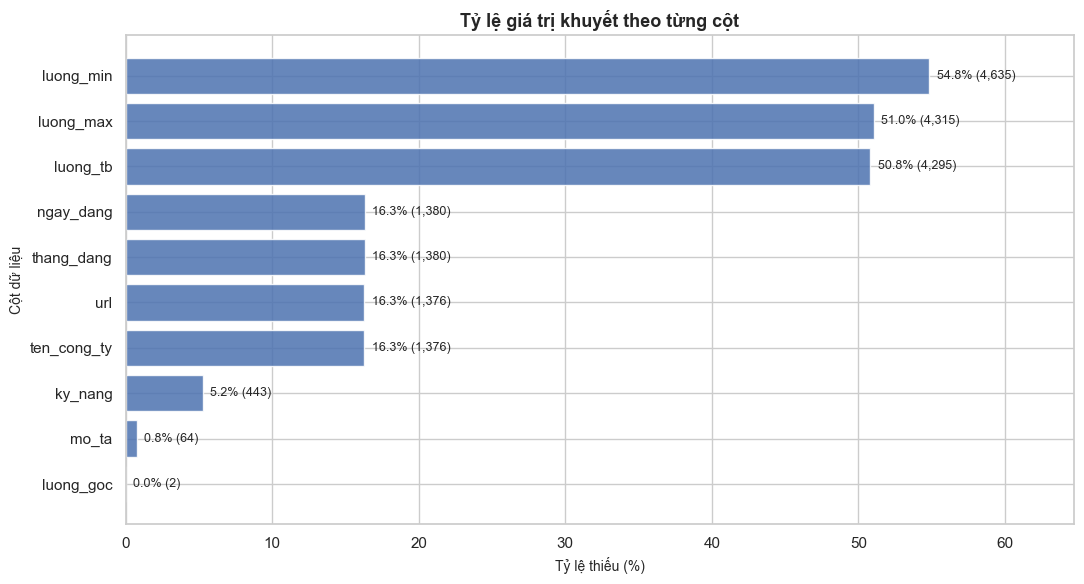

In [19]:
# Kiểm tra số lượng và tỷ lệ giá trị khuyết ở từng cột
missing_summary = pd.DataFrame({
    'so_luong_thieu': df.isna().sum(),
    'ty_le_thieu_%': (df.isna().mean() * 100).round(2)
}).sort_values('ty_le_thieu_%', ascending=False)

missing_nonzero = missing_summary[missing_summary['so_luong_thieu'] > 0]

print("=== Tổng quan dữ liệu khuyết ===")
print(f"Số cột có giá trị khuyết: {len(missing_nonzero)}/{df.shape[1]} cột")
print(f"Số cột không có giá trị khuyết: {(missing_summary['so_luong_thieu'] == 0).sum()}/{df.shape[1]} cột")
print(f"Tổng số ô dữ liệu khuyết: {int(df.isna().sum().sum()):,} ô")

print("\n=== Các cột có dữ liệu khuyết ===")
display(missing_nonzero)

# ─ Biểu đồ ─
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    plot_data = missing_nonzero.sort_values('ty_le_thieu_%', ascending=True)
    bars = ax.barh(
        plot_data.index,
        plot_data['ty_le_thieu_%'],
        color='#4C72B0', alpha=0.85, edgecolor='white'
    )

    for bar, (_, row) in zip(bars, plot_data.iterrows()):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{row['ty_le_thieu_%']:.1f}% ({int(row['so_luong_thieu']):,})",
            va='center', fontsize=9
        )

    ax.set_title("Tỷ lệ giá trị khuyết theo từng cột", fontsize=13, fontweight='bold')
    ax.set_xlabel("Tỷ lệ thiếu (%)", fontsize=10)
    ax.set_ylabel("Cột dữ liệu", fontsize=10)
    ax.set_xlim(0, max(plot_data['ty_le_thieu_%']) * 1.18)
    plt.tight_layout()
    plt.show()
else:
    print("Không phát hiện giá trị khuyết trong bộ dữ liệu.")


##### Nhận xét:

- Có **10/18 cột** xuất hiện giá trị khuyết, trong đó nhóm cột lương thiếu nhiều nhất.
- `luong_min`, `luong_max`, `luong_tb` lần lượt thiếu khoảng **54.8%**, **51.1%** và **50.8%** do nhiều tin tuyển dụng để lương ở dạng thỏa thuận hoặc không công khai mức lương cụ thể.
- `ngay_dang`, `thang_dang`, `ten_cong_ty` và `url` thiếu khoảng **16.3%**, cần lưu ý khi phân tích theo thời gian hoặc truy vết nguồn tin.
- `ky_nang` thiếu **5.2%**, `mo_ta` thiếu **0.8%**, mức thiếu không quá lớn so với toàn bộ dữ liệu.
- Khi phân tích lương nên lọc riêng các dòng có lương số; không nên xóa toàn bộ dòng thiếu lương vì sẽ làm mất hơn một nửa bộ dữ liệu.

### **2.3. Kiểm tra tính hợp lệ và bất thường**
Kiểm tra xem có lương âm, lương bằng 0, định dạng ngày đăng (`ngay_dang`) hay định dạng tháng đăng (`thang_dang`) nào bị sai quy chuẩn không.

In [20]:
# Kiểm tra dữ liệu bất thường theo yêu cầu: lương âm, lương bằng 0, định dạng ngày/tháng đăng
salary_cols = ['luong_min', 'luong_max', 'luong_tb']

salary_check_rows = []
for col in salary_cols:
    salary_check_rows.append({
        'kiem_tra': f'{col} < 0',
        'so_dong_bat_thuong': int((df[col] < 0).sum()),
        'ghi_chu': 'Lương âm là không hợp lệ'
    })
    salary_check_rows.append({
        'kiem_tra': f'{col} = 0',
        'so_dong_bat_thuong': int((df[col] == 0).sum()),
        'ghi_chu': 'Lương bằng 0 cần kiểm tra lại nếu có'
    })

mask_min_max = df['luong_min'].notna() & df['luong_max'].notna()
mask_full_salary = mask_min_max & df['luong_tb'].notna()

salary_check_rows.extend([
    {
        'kiem_tra': 'luong_min > luong_max',
        'so_dong_bat_thuong': int((mask_min_max & (df['luong_min'] > df['luong_max'])).sum()),
        'ghi_chu': 'Lương tối thiểu không được lớn hơn lương tối đa'
    },
    {
        'kiem_tra': 'luong_tb nằm ngoài khoảng [luong_min, luong_max]',
        'so_dong_bat_thuong': int((mask_full_salary & ((df['luong_tb'] < df['luong_min']) | (df['luong_tb'] > df['luong_max']))).sum()),
        'ghi_chu': 'Chỉ kiểm tra trên dòng có đủ min, max và trung bình'
    }
])

salary_check = pd.DataFrame(salary_check_rows)
print("=== Kiểm tra bất thường ở các cột lương ===")
display(salary_check)

# Kiểm tra định dạng ngày đăng và tháng đăng
ngay_dang_parsed = pd.to_datetime(df['ngay_dang'], format='%Y-%m-%d', errors='coerce')
thang_dang_parsed = pd.to_datetime(df['thang_dang'], format='%Y-%m', errors='coerce')

invalid_ngay = df['ngay_dang'].notna() & ngay_dang_parsed.isna()
invalid_thang = df['thang_dang'].notna() & thang_dang_parsed.isna()

valid_both_dates = (
    df['ngay_dang'].notna() & df['thang_dang'].notna() &
    ngay_dang_parsed.notna() & thang_dang_parsed.notna()
)
thang_from_ngay = ngay_dang_parsed.dt.to_period('M').astype(str)
month_mismatch = valid_both_dates & (df['thang_dang'] != thang_from_ngay)

date_check = pd.DataFrame({
    'kiem_tra': [
        "ngay_dang sai định dạng YYYY-MM-DD",
        "thang_dang sai định dạng YYYY-MM",
        "thang_dang không khớp với tháng của ngay_dang"
    ],
    'so_dong_bat_thuong': [
        int(invalid_ngay.sum()),
        int(invalid_thang.sum()),
        int(month_mismatch.sum())
    ],
    'so_dong_thieu': [
        int(df['ngay_dang'].isna().sum()),
        int(df['thang_dang'].isna().sum()),
        np.nan
    ]
})

print("\n=== Kiểm tra định dạng ngày/tháng đăng ===")
display(date_check)

print("\n=== Khoảng thời gian ghi nhận được ===")
print(f"ngay_dang: từ {ngay_dang_parsed.min().date()} đến {ngay_dang_parsed.max().date()}")
print(f"thang_dang: từ {thang_dang_parsed.min().strftime('%Y-%m')} đến {thang_dang_parsed.max().strftime('%Y-%m')}")

# Kiểm tra trùng lặp cơ bản
duplicate_rows = int(df.duplicated().sum())
duplicate_urls = int(df[df['url'].notna()].duplicated(subset=['url']).sum())

duplicate_check = pd.DataFrame({
    'kiem_tra': ['Dòng trùng hoàn toàn', 'URL trùng trên các dòng không rỗng'],
    'so_dong_bat_thuong': [duplicate_rows, duplicate_urls],
    'ty_le_%': [round(duplicate_rows / len(df) * 100, 3), round(duplicate_urls / df['url'].notna().sum() * 100, 3)]
})

print("\n=== Kiểm tra trùng lặp ===")
display(duplicate_check)

if duplicate_rows > 0:
    print("\nVí dụ dòng trùng hoàn toàn:")
    display(df[df.duplicated(keep=False)].head())


=== Kiểm tra bất thường ở các cột lương ===


,kiem_tra,so_dong_bat_thuong,ghi_chu
0,luong_min < 0,0,Lương âm là không hợp lệ
1,luong_min = 0,0,Lương bằng 0 cần kiểm tra lại nếu có
2,luong_max < 0,0,Lương âm là không hợp lệ
3,luong_max = 0,0,Lương bằng 0 cần kiểm tra lại nếu có
4,luong_tb < 0,0,Lương âm là không hợp lệ
5,luong_tb = 0,0,Lương bằng 0 cần kiểm tra lại nếu có
6,luong_min > luong_max,0,Lương tối thiểu không được lớn hơn lương tối đa
7,"luong_tb nằm ngoài khoảng [luong_min, luong_max]",0,"Chỉ kiểm tra trên dòng có đủ min, max và trung..."



=== Kiểm tra định dạng ngày/tháng đăng ===


,kiem_tra,so_dong_bat_thuong,so_dong_thieu
0,ngay_dang sai định dạng YYYY-MM-DD,0,1380.0
1,thang_dang sai định dạng YYYY-MM,0,1380.0
2,thang_dang không khớp với tháng của ngay_dang,0,NaN



=== Khoảng thời gian ghi nhận được ===
ngay_dang: từ 2022-06-01 đến 2026-06-12
thang_dang: từ 2022-06 đến 2026-06

=== Kiểm tra trùng lặp ===


,kiem_tra,so_dong_bat_thuong,ty_le_%
0,Dòng trùng hoàn toàn,1,0.012
1,URL trùng trên các dòng không rỗng,0,0.000



Ví dụ dòng trùng hoàn toàn:


,ten_cong_viec,ten_cong_ty,nhom_vi_tri,cap_do_kinh_nghiem,tinh_thanh,vung_mien,luong_goc,luong_min,luong_max,luong_tb,loai_luong,ky_nang,mo_ta,hinh_thuc_lam_viec,ngay_dang,thang_dang,nguon,url
7998,Lập Trình Viên C#,NaN,Software Development,Middle,Khác,Khác,0.0 triệu,NaN,NaN,NaN,negotiable,"NET Core, C# (Windows Form), MySQL, SQL Server...",Tham gia bảo trì và phát triển hệ thống phần m...,Full-time,NaN,NaN,VietJobs,NaN
8000,Lập Trình Viên C#,NaN,Software Development,Middle,Khác,Khác,0.0 triệu,NaN,NaN,NaN,negotiable,"NET Core, C# (Windows Form), MySQL, SQL Server...",Tham gia bảo trì và phát triển hệ thống phần m...,Full-time,NaN,NaN,VietJobs,NaN


##### Nhận xét:

- Không phát hiện lương âm hoặc lương bằng 0 ở cả ba cột `luong_min`, `luong_max`, `luong_tb`.
- Không có dòng nào bị lỗi `luong_min > luong_max`; các dòng có đủ min, max và trung bình cũng không có `luong_tb` nằm ngoài khoảng lương hợp lệ.
- `ngay_dang` và `thang_dang` không có lỗi định dạng trên các dòng không rỗng; `thang_dang` cũng khớp với tháng được tách từ `ngay_dang`.
- Dữ liệu thời gian trải từ **2022-06-01 đến 2026-06-12** theo `ngay_dang`, phù hợp để phân tích xu hướng tuyển dụng theo tháng/năm.
- Có **1 dòng trùng hoàn toàn**; tỷ lệ rất nhỏ nên có thể kiểm tra và xử lý trước khi dựng dashboard cuối cùng.

## **3. Phân tích phân bố các biến định tính (Categorical Features) (Nhật Vy)**

### **3.1. Phân bố các nhóm công việc tuyển dụng (`nhom_vi_tri`)**
Thống kê số lượng và tỷ lệ % của các nhóm vị trí công việc IT trong bộ dữ liệu.

=== Phân bố nhóm vị trí công việc (nhom_vi_tri) ===


,so_luong,ty_le_%
nhom_vi_tri,,
Software Development,2503,29.61
Other,982,11.62
AI / ML / Data Science,937,11.09
Mobile / Game / Embedded,753,8.91
IT Support / ERP,695,8.22
QA / Testing,499,5.90
Cloud / DevOps / SRE,473,5.60
Management / Architecture,460,5.44
Product / Business / UX,457,5.41


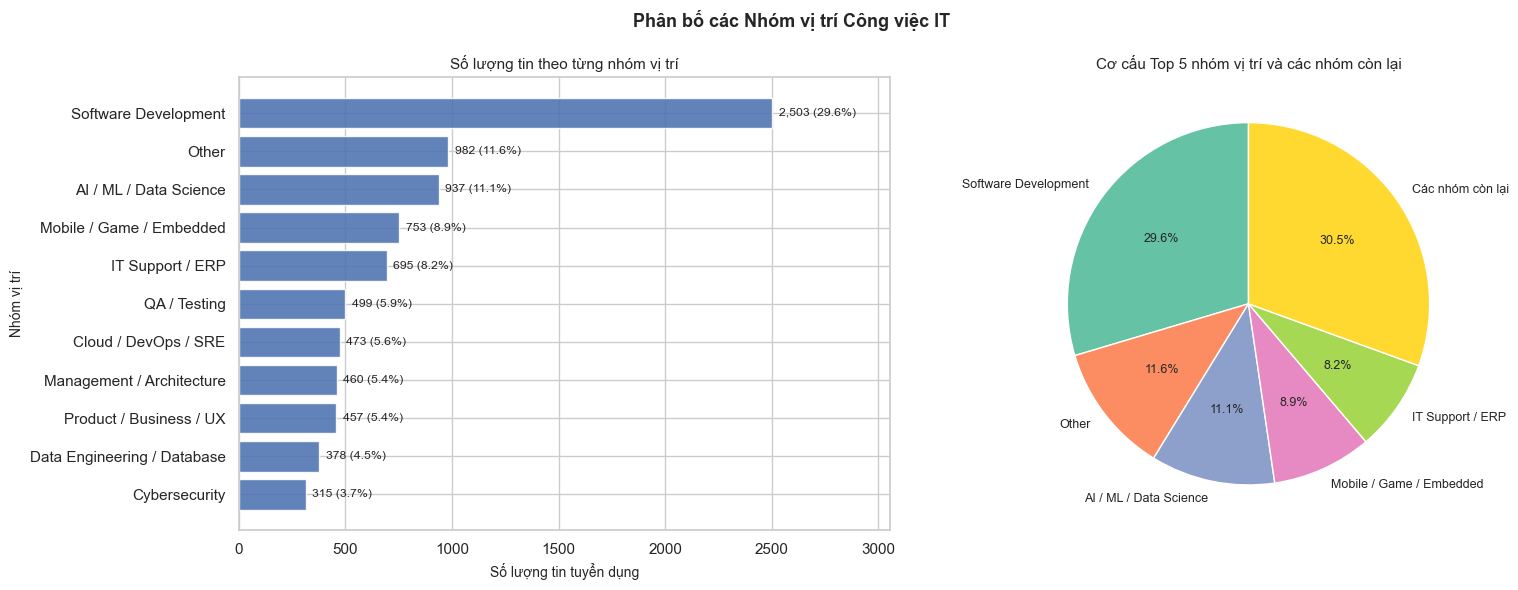

In [21]:
# Thống kê số lượng và tỷ lệ % theo nhóm vị trí công việc
role_counts = df['nhom_vi_tri'].value_counts(dropna=False)
role_summary = pd.DataFrame({
    'so_luong': role_counts,
    'ty_le_%': (role_counts / len(df) * 100).round(2)
})

print("=== Phân bố nhóm vị trí công việc (nhom_vi_tri) ===")
display(role_summary)

# Chuẩn bị dữ liệu gom nhóm nhỏ cho biểu đồ tròn
role_top5 = role_counts.head(5)
role_pie = pd.concat([
    role_top5,
    pd.Series({'Các nhóm còn lại': role_counts.iloc[5:].sum()})
])

# ── Biểu đồ ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle("Phân bố các Nhóm vị trí Công việc IT", fontsize=13, fontweight='bold')

# --- Bar chart: toàn bộ nhóm vị trí ---
ax1 = axes[0]
plot_roles = role_summary.sort_values('so_luong', ascending=True)
bars = ax1.barh(
    plot_roles.index,
    plot_roles['so_luong'],
    color='#4C72B0', alpha=0.88, edgecolor='white'
)

for bar, (_, row) in zip(bars, plot_roles.iterrows()):
    ax1.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height()/2,
        f"{int(row['so_luong']):,} ({row['ty_le_%']:.1f}%)",
        va='center', fontsize=8.8
    )

ax1.set_xlabel("Số lượng tin tuyển dụng", fontsize=10)
ax1.set_ylabel("Nhóm vị trí", fontsize=10)
ax1.set_title("Số lượng tin theo từng nhóm vị trí", fontsize=11)
ax1.set_xlim(0, role_summary['so_luong'].max() * 1.22)

# --- Pie chart: top 5 + các nhóm còn lại ---
ax2 = axes[1]
colors = sns.color_palette('Set2', len(role_pie))
ax2.pie(
    role_pie.values,
    labels=role_pie.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 9}
)
ax2.set_title("Cơ cấu Top 5 nhóm vị trí và các nhóm còn lại", fontsize=11)

plt.tight_layout()
plt.show()


##### Nhận xét:

- **Software Development** là nhóm có số lượng tin tuyển dụng cao nhất với **2,503 tin**, chiếm khoảng **29.6%** toàn bộ dữ liệu.
- Nhóm **Other** đứng thứ hai với **982 tin** (**11.6%**), cho thấy vẫn còn một phần tin chưa được gom vào nhóm chuyên môn cụ thể.
- **AI / ML / Data Science** có **937 tin** (**11.1%**), là nhóm lớn thứ ba trong bộ dữ liệu.
- Các nhóm còn lại phân bố thấp hơn, dao động từ khoảng **3.7% đến 8.9%**; thấp nhất là **Cybersecurity** với **315 tin** (**3.7%**).
- Cơ cấu nhóm vị trí không đồng đều, trong đó Software Development chiếm tỷ trọng nổi bật so với các nhóm khác.

### **3.2. Phân bố các cấp độ kinh nghiệm yêu cầu (`cap_do_kinh_nghiem`)**
Thống kê tần suất và tỷ lệ của các cấp bậc kinh nghiệm.

=== Phân bố cấp độ kinh nghiệm (cap_do_kinh_nghiem) ===


,so_luong,ty_le_%
cap_do_kinh_nghiem,,
Intern,193,2.28
Fresher,370,4.38
Junior,596,7.05
Middle,1022,12.09
Senior,1444,17.08
Không rõ,4827,57.11



=== Cơ cấu cấp bậc trong các dòng có thông tin kinh nghiệm rõ ràng ===


,so_luong,ty_le_%_trong_nhom_co_thong_tin
cap_do_kinh_nghiem,,
Intern,193,5.32
Fresher,370,10.21
Junior,596,16.44
Middle,1022,28.19
Senior,1444,39.83


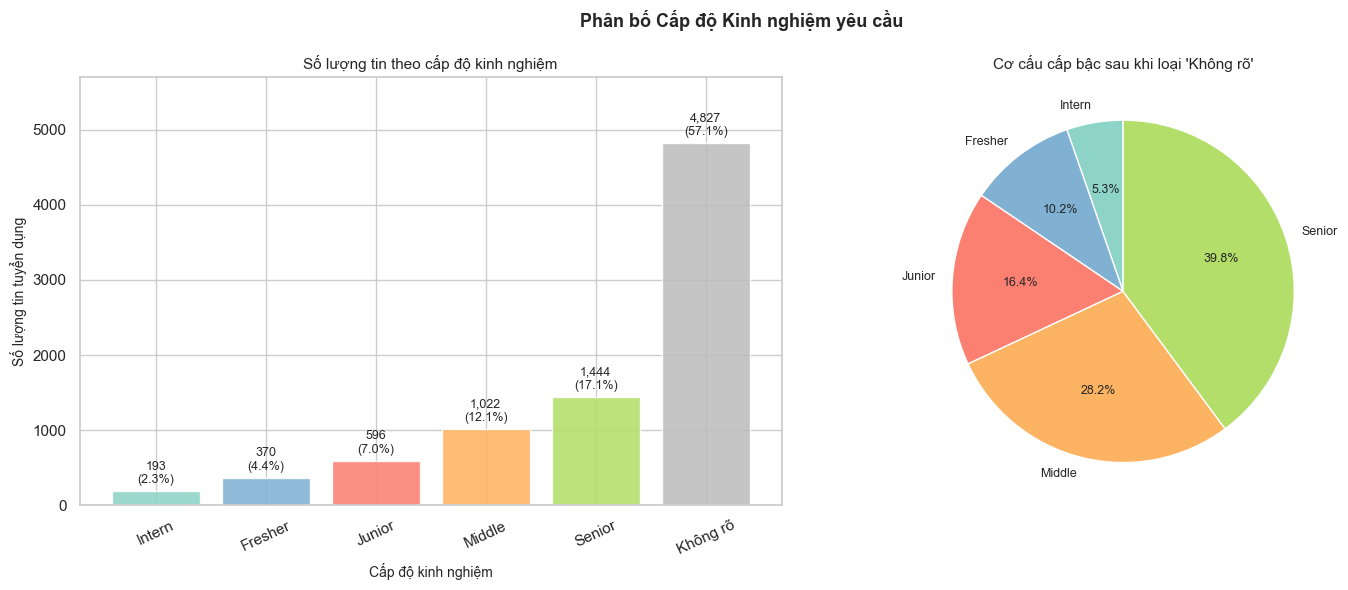

In [22]:
# Thống kê số lượng và tỷ lệ % theo cấp độ kinh nghiệm
exp_order = ['Intern', 'Fresher', 'Junior', 'Middle', 'Senior', 'Không rõ']
exp_counts = df['cap_do_kinh_nghiem'].value_counts(dropna=False).reindex(exp_order)
exp_summary = pd.DataFrame({
    'so_luong': exp_counts,
    'ty_le_%': (exp_counts / len(df) * 100).round(2)
})

print("=== Phân bố cấp độ kinh nghiệm (cap_do_kinh_nghiem) ===")
display(exp_summary)

# Tách riêng nhóm xác định được cấp bậc để xem cơ cấu trong phần có thông tin rõ
exp_known = df[df['cap_do_kinh_nghiem'] != 'Không rõ']['cap_do_kinh_nghiem']
known_counts = exp_known.value_counts().reindex(exp_order[:-1])
known_summary = pd.DataFrame({
    'so_luong': known_counts,
    'ty_le_%_trong_nhom_co_thong_tin': (known_counts / len(exp_known) * 100).round(2)
})

print("\n=== Cơ cấu cấp bậc trong các dòng có thông tin kinh nghiệm rõ ràng ===")
display(known_summary)

# ── Biểu đồ ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Phân bố Cấp độ Kinh nghiệm yêu cầu", fontsize=13, fontweight='bold')

palette_exp = ['#8dd3c7', '#80b1d3', '#fb8072', '#fdb462', '#b3de69', '#bdbdbd']

# --- Bar chart: toàn bộ dữ liệu ---
ax1 = axes[0]
bars = ax1.bar(
    exp_summary.index,
    exp_summary['so_luong'],
    color=palette_exp, alpha=0.88, edgecolor='white'
)
for bar, (_, row) in zip(bars, exp_summary.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 60,
        f"{int(row['so_luong']):,}\n({row['ty_le_%']:.1f}%)",
        ha='center', va='bottom', fontsize=9
    )
ax1.set_title("Số lượng tin theo cấp độ kinh nghiệm", fontsize=11)
ax1.set_xlabel("Cấp độ kinh nghiệm", fontsize=10)
ax1.set_ylabel("Số lượng tin tuyển dụng", fontsize=10)
ax1.set_ylim(0, exp_summary['so_luong'].max() * 1.18)
ax1.tick_params(axis='x', labelrotation=25)

# --- Pie chart: chỉ xét các dòng có cấp bậc rõ ràng ---
ax2 = axes[1]
ax2.pie(
    known_counts.values,
    labels=known_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=palette_exp[:-1],
    textprops={'fontsize': 9}
)
ax2.set_title("Cơ cấu cấp bậc sau khi loại 'Không rõ'", fontsize=11)

plt.tight_layout()
plt.show()


##### Nhận xét:

- Nhóm **Không rõ** chiếm tỷ lệ lớn nhất với **4,827 tin** (**57.1%**), nghĩa là hơn một nửa tin tuyển dụng không thể hiện rõ cấp độ kinh nghiệm sau xử lý.
- Trong toàn bộ dữ liệu, **Senior** chiếm **17.1%**, **Middle** chiếm **12.1%**, **Junior** chiếm **7.1%**, **Fresher** chiếm **4.4%**, còn **Intern** chỉ chiếm **2.3%**.
- Nếu chỉ xét các dòng có cấp bậc rõ ràng, Senior là nhóm lớn nhất, tiếp theo là Middle và Junior.
- Tỷ lệ Intern và Fresher thấp cho thấy nhóm cơ hội đầu vào xuất hiện ít hơn so với các vị trí yêu cầu kinh nghiệm.
- Khi phân tích theo cấp bậc, cần ghi chú riêng nhóm **Không rõ** vì nhóm này ảnh hưởng mạnh đến cơ cấu tổng thể.

### **3.3. Phân bố theo địa lý & mô hình công việc (`tinh_thanh`, `vung_mien`, `hinh_thuc_lam_viec`)**
Khảo sát sự phân bố địa lý các hub công nghệ và tỷ lệ các hình thức làm việc.

=== Top tỉnh/thành theo số lượng tin tuyển dụng ===


,so_luong,ty_le_%
tinh_thanh,,
TP.HCM,4235,50.11
Hà Nội,3143,37.19
Khác,799,9.45
Đà Nẵng,52,0.62
Bắc Ninh,33,0.39
Hải Phòng,29,0.34
Thái Nguyên,20,0.24
Khánh Hòa,19,0.22
Đồng Nai,18,0.21



=== Phân bố theo vùng miền ===


,so_luong,ty_le_%
vung_mien,,
Nam,4281,50.65
Bắc,3252,38.48
Khác,799,9.45
Trung,108,1.28
Từ xa / Remote,12,0.14



=== Phân bố theo hình thức làm việc ===


,so_luong,ty_le_%
hinh_thuc_lam_viec,,
Full-time,6618,78.30
Khác,1650,19.52
Internship,90,1.06
Không rõ,45,0.53
Contract,26,0.31
Part-time,23,0.27


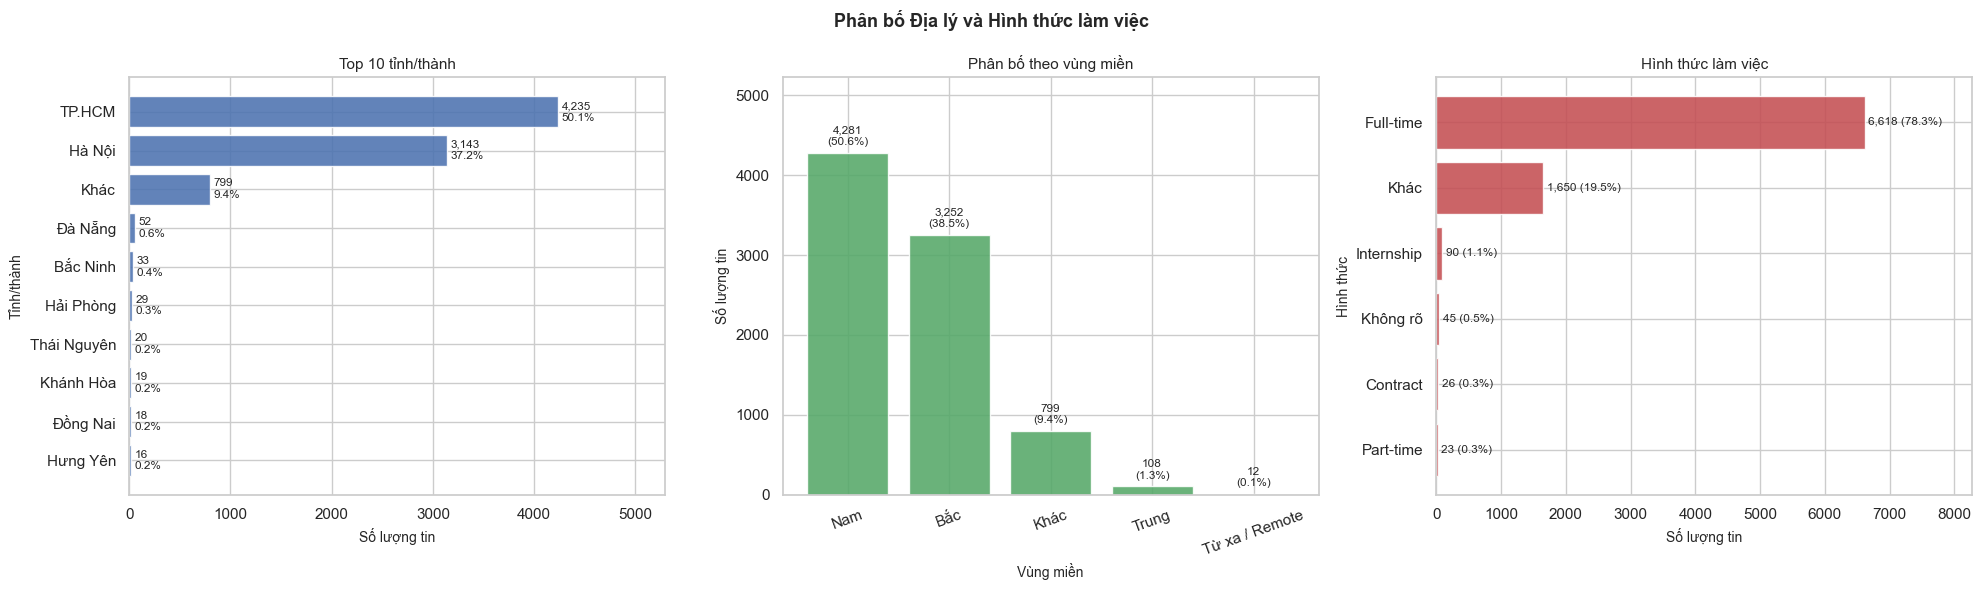

In [23]:
# Thống kê phân bố theo tỉnh/thành, vùng miền và hình thức làm việc
city_counts = df['tinh_thanh'].value_counts(dropna=False)
region_counts = df['vung_mien'].value_counts(dropna=False)
work_type_counts = df['hinh_thuc_lam_viec'].value_counts(dropna=False)

city_summary = pd.DataFrame({
    'so_luong': city_counts,
    'ty_le_%': (city_counts / len(df) * 100).round(2)
})
region_summary = pd.DataFrame({
    'so_luong': region_counts,
    'ty_le_%': (region_counts / len(df) * 100).round(2)
})
work_type_summary = pd.DataFrame({
    'so_luong': work_type_counts,
    'ty_le_%': (work_type_counts / len(df) * 100).round(2)
})

print("=== Top tỉnh/thành theo số lượng tin tuyển dụng ===")
display(city_summary.head(10))

print("\n=== Phân bố theo vùng miền ===")
display(region_summary)

print("\n=== Phân bố theo hình thức làm việc ===")
display(work_type_summary)

# ── Biểu đồ ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Phân bố Địa lý và Hình thức làm việc", fontsize=13, fontweight='bold')

# --- Top 10 tỉnh/thành ---
ax1 = axes[0]
top_city = city_summary.head(10).sort_values('so_luong', ascending=True)
bars1 = ax1.barh(top_city.index, top_city['so_luong'], color='#4C72B0', alpha=0.88, edgecolor='white')
for bar, (_, row) in zip(bars1, top_city.iterrows()):
    ax1.text(
        bar.get_width() + 35,
        bar.get_y() + bar.get_height()/2,
        f"{int(row['so_luong']):,}\n{row['ty_le_%']:.1f}%",
        va='center', fontsize=8.5
    )
ax1.set_title("Top 10 tỉnh/thành", fontsize=11)
ax1.set_xlabel("Số lượng tin", fontsize=10)
ax1.set_ylabel("Tỉnh/thành", fontsize=10)
ax1.set_xlim(0, top_city['so_luong'].max() * 1.25)

# --- Vùng miền ---
ax2 = axes[1]
bars2 = ax2.bar(region_summary.index, region_summary['so_luong'], color='#55A868', alpha=0.88, edgecolor='white')
for bar, (_, row) in zip(bars2, region_summary.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 70,
        f"{int(row['so_luong']):,}\n({row['ty_le_%']:.1f}%)",
        ha='center', va='bottom', fontsize=8.5
    )
ax2.set_title("Phân bố theo vùng miền", fontsize=11)
ax2.set_xlabel("Vùng miền", fontsize=10)
ax2.set_ylabel("Số lượng tin", fontsize=10)
ax2.set_ylim(0, region_summary['so_luong'].max() * 1.22)
ax2.tick_params(axis='x', labelrotation=20)

# --- Hình thức làm việc ---
ax3 = axes[2]
work_plot = work_type_summary.sort_values('so_luong', ascending=True)
bars3 = ax3.barh(work_plot.index, work_plot['so_luong'], color='#C44E52', alpha=0.88, edgecolor='white')
for bar, (_, row) in zip(bars3, work_plot.iterrows()):
    ax3.text(
        bar.get_width() + 55,
        bar.get_y() + bar.get_height()/2,
        f"{int(row['so_luong']):,} ({row['ty_le_%']:.1f}%)",
        va='center', fontsize=8.5
    )
ax3.set_title("Hình thức làm việc", fontsize=11)
ax3.set_xlabel("Số lượng tin", fontsize=10)
ax3.set_ylabel("Hình thức", fontsize=10)
ax3.set_xlim(0, work_plot['so_luong'].max() * 1.25)

plt.tight_layout()
plt.show()


##### Nhận xét:

- Tin tuyển dụng tập trung chủ yếu tại **TP.HCM** với **4,235 tin** (**50.1%**) và **Hà Nội** với **3,143 tin** (**37.2%**).
- Hai địa phương TP.HCM và Hà Nội cộng lại chiếm khoảng **87.3%** toàn bộ dữ liệu, vượt xa các tỉnh/thành còn lại.
- Theo vùng miền, khu vực **Nam** chiếm **50.7%**, khu vực **Bắc** chiếm **38.5%**, còn **Trung** chỉ chiếm **1.3%**.
- Theo hình thức làm việc, **Full-time** chiếm ưu thế rõ rệt với **6,618 tin** (**78.3%**); nhóm **Khác** chiếm **19.5%**.
- Các hình thức **Internship**, **Contract**, **Part-time** và **Không rõ** đều có tỷ lệ nhỏ, mỗi nhóm chỉ khoảng từ **0.3% đến 1.1%**.

## **4. Phân tích phân bố các biến định lượng (Numerical Features) (Kim Yến)**

### **4.1. Phân phối mức lương trung bình (`luong_tb`)**
Vẽ biểu đồ phân phối tần suất (Histogram & KDE) của cột lương trung bình để khảo sát hình dáng phân phối lương.

*Lưu ý: Chỉ thực hiện trên tập con có giá trị lương số thực tế.*

Tổng bộ dữ liệu     : 8,452 dòng
Có lương số thực tế  : 4,157 dòng  (49.2%)
Lương thỏa thuận     : 4,295 dòng  (50.8%) → bị loại khỏi biểu đồ này

Thống kê mô tả – luong_tb (triệu VND/tháng):
Số dòng          4157.00
Trung bình         25.62
Độ lệch chuẩn      19.24
Nhỏ nhất            1.00
Q1 (25%)           12.50
Trung vị           20.00
Q3 (75%)           33.75
Lớn nhất          250.00


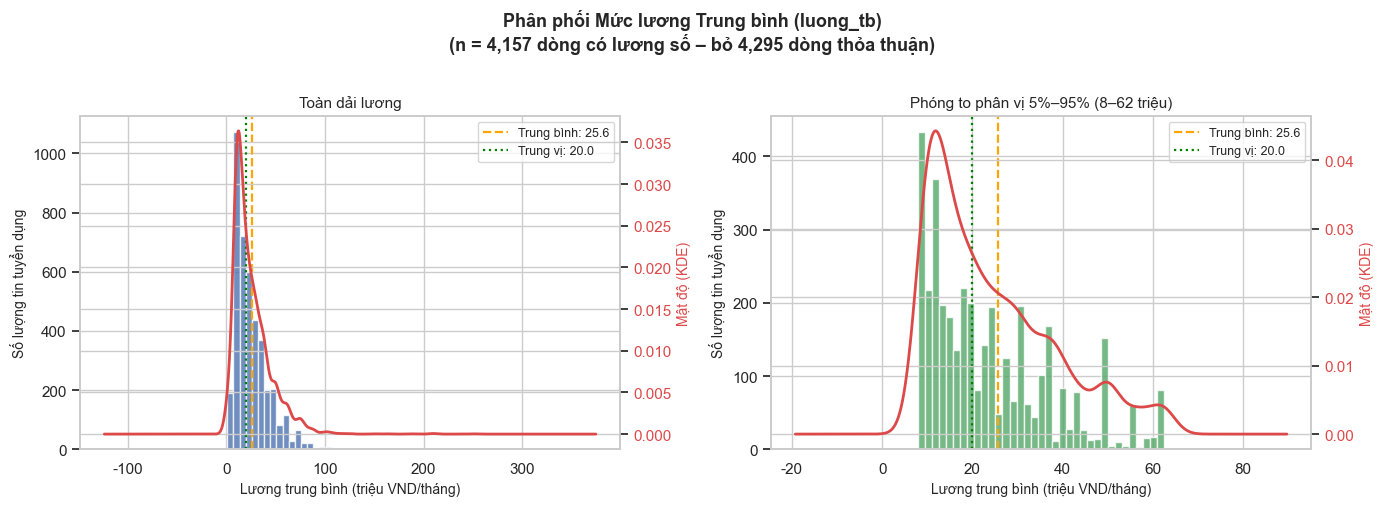

In [ ]:
# Lọc tập con có lương số thực tế (bỏ qua 'thỏa thuận' – NaN)
df_salary = df[df['luong_tb'].notna() & (df['luong_tb'] > 0)].copy()

n_total   = len(df)
n_salary  = len(df_salary)
n_nego    = n_total - n_salary

print(f"Tổng bộ dữ liệu     : {n_total:,} dòng")
print(f"Có lương số thực tế  : {n_salary:,} dòng  ({n_salary/n_total*100:.1f}%)")
print(f"Lương thỏa thuận     : {n_nego:,} dòng  ({n_nego/n_total*100:.1f}%) → bị loại khỏi biểu đồ này")
print()

desc = df_salary['luong_tb'].describe().rename({
    'count': 'Số dòng', 'mean': 'Trung bình', 'std': 'Độ lệch chuẩn',
    'min': 'Nhỏ nhất', '25%': 'Q1 (25%)', '50%': 'Trung vị',
    '75%': 'Q3 (75%)', 'max': 'Lớn nhất'
})
print("Thống kê mô tả – luong_tb (triệu VND/tháng):")
print(desc.round(2).to_string())

# ── Biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Phân phối Mức lương Trung bình (luong_tb)\n"
    f"(n = {n_salary:,} dòng có lương số – bỏ {n_nego:,} dòng thỏa thuận)",
    fontsize=13, fontweight='bold', y=1.01
)

# --- Histogram + KDE toàn bộ dải lương ---
ax1 = axes[0]
ax1.hist(
    df_salary['luong_tb'],
    bins=40, color='#4C72B0', edgecolor='white', alpha=0.8
)
ax2_twin = ax1.twinx()
df_salary['luong_tb'].plot.kde(ax=ax2_twin, color='#DD4949', linewidth=2)
ax2_twin.set_ylabel("Mật độ (KDE)", color='#DD4949', fontsize=10)
ax2_twin.tick_params(axis='y', labelcolor='#DD4949')

mean_val   = df_salary['luong_tb'].mean()
median_val = df_salary['luong_tb'].median()
ax1.axvline(mean_val,   color='orange', linestyle='--', linewidth=1.6, label=f'Trung bình: {mean_val:.1f}')
ax1.axvline(median_val, color='green',  linestyle=':',  linewidth=1.6, label=f'Trung vị: {median_val:.1f}')
ax1.set_xlabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax1.set_ylabel("Số lượng tin tuyển dụng", fontsize=10)
ax1.set_title("Toàn dải lương", fontsize=11)
ax1.legend(fontsize=9)

# --- Histogram + KDE zoom vào phân vị 5–95% (loại bỏ đuôi dài) ---
p5  = df_salary['luong_tb'].quantile(0.05)
p95 = df_salary['luong_tb'].quantile(0.95)
df_zoom = df_salary[df_salary['luong_tb'].between(p5, p95)]

ax3 = axes[1]
ax3.hist(
    df_zoom['luong_tb'],
    bins=35, color='#55A868', edgecolor='white', alpha=0.8
)
ax4_twin = ax3.twinx()
df_zoom['luong_tb'].plot.kde(ax=ax4_twin, color='#DD4949', linewidth=2)
ax4_twin.set_ylabel("Mật độ (KDE)", color='#DD4949', fontsize=10)
ax4_twin.tick_params(axis='y', labelcolor='#DD4949')

ax3.axvline(mean_val,   color='orange', linestyle='--', linewidth=1.6, label=f'Trung bình: {mean_val:.1f}')
ax3.axvline(median_val, color='green',  linestyle=':',  linewidth=1.6, label=f'Trung vị: {median_val:.1f}')
ax3.set_xlabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax3.set_ylabel("Số lượng tin tuyển dụng", fontsize=10)
ax3.set_title(f"Phóng to phân vị 5%–95% ({p5:.0f}–{p95:.0f} triệu)", fontsize=11)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

##### Nhận xét:
- Phân phối có hình dạng **lệch phải (right-skewed)** rõ ràng – đặc trưng điển hình của phân phối lương trên thị trường lao động.
- **Trung vị (20.0 triệu) thấp hơn trung bình (25.6 triệu)** khoảng 5.6 triệu, phản ánh việc một nhóm nhỏ vị trí lương rất cao đang "kéo" trung bình lên.
- Vùng tập trung mật độ cao nhất nằm trong khoảng **10 – 35 triệu/tháng**, chiếm phần lớn số tin tuyển dụng.
- Sau khi zoom 5%–95%, đường KDE cho thấy đỉnh phân phối (mode) ở khoảng **12 – 15 triệu/tháng** – đây là mức lương phổ biến nhất trên thị trường.
- Đuôi phải kéo dài đến 250 triệu/tháng – gần như toàn bộ là vị trí quản lý cấp cao hoặc công ty nước ngoài.

→ **~50.8% tin tuyển dụng không công khai lương** (thỏa thuận) đã bị loại khỏi phân tích này – kết quả phản ánh phân khúc có công khai mức lương, **không đại diện toàn bộ thị trường**.

### **4.2. Phân phối lương tối thiểu và tối đa (`luong_min`, `luong_max`)**
Khảo sát phân phối biên độ lương min/max để hiểu khoảng giới hạn chi trả phổ biến của doanh nghiệp.

Số dòng có đủ luong_min và luong_max: 3,797

Thống kê mô tả:
       Lương tối thiểu (triệu)  Lương tối đa (triệu)
count                  3797.00               3797.00
mean                     17.81                 31.32
std                      14.65                 23.70
min                       1.00                  1.00
25%                       9.00                 15.00
50%                      15.00                 25.00
75%                      25.00                 40.00
max                     208.33                375.00


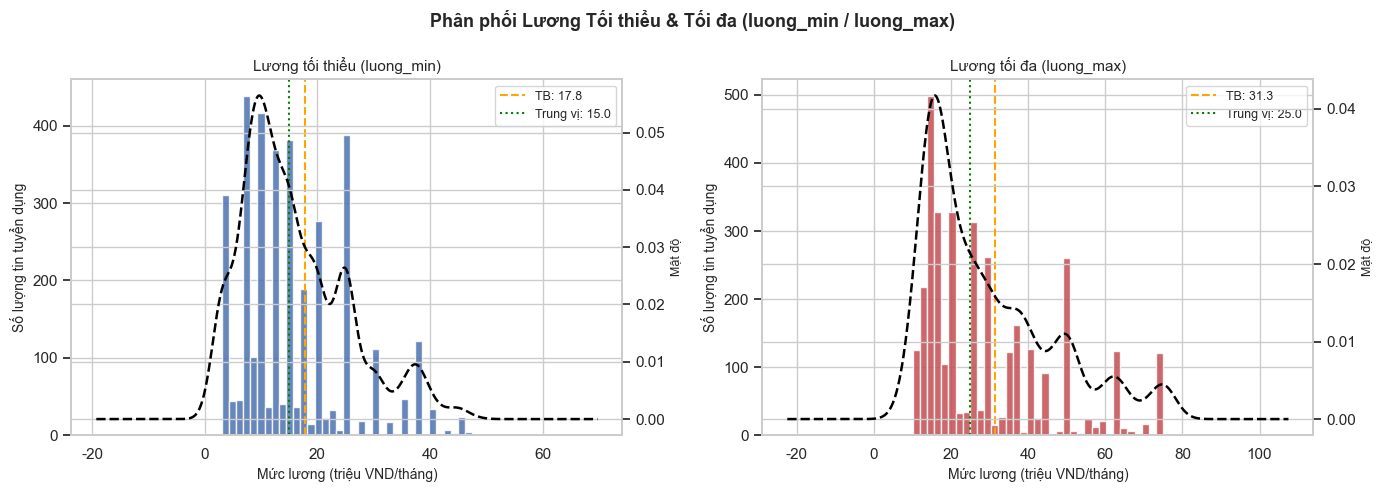

In [25]:
# Chỉ dùng dòng có cả hai giá trị min và max (loại dòng 'from' hoặc 'to' đơn thuần)
df_range = df_salary[df_salary['luong_min'].notna() & df_salary['luong_max'].notna()].copy()
print(f"Số dòng có đủ luong_min và luong_max: {len(df_range):,}")

desc_minmax = df_range[['luong_min', 'luong_max']].describe().round(2)
desc_minmax.columns = ['Lương tối thiểu (triệu)', 'Lương tối đa (triệu)']
print("\nThống kê mô tả:")
print(desc_minmax.to_string())

# ── Biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Phân phối Lương Tối thiểu & Tối đa (luong_min / luong_max)",
    fontsize=13, fontweight='bold'
)

cols_info = [
    ('luong_min', '#4C72B0', 'Lương tối thiểu (luong_min)'),
    ('luong_max', '#C44E52', 'Lương tối đa (luong_max)'),
]

for ax, (col, color, title) in zip(axes, cols_info):
    # Zoom 5–95% để tránh đuôi dài
    p5_c  = df_range[col].quantile(0.05)
    p95_c = df_range[col].quantile(0.95)
    data_zoom = df_range[df_range[col].between(p5_c, p95_c)][col]

    ax.hist(data_zoom, bins=35, color=color, edgecolor='white', alpha=0.85)
    ax_kde = ax.twinx()
    data_zoom.plot.kde(ax=ax_kde, color='black', linewidth=1.8, linestyle='--')
    ax_kde.set_ylabel('Mật độ', fontsize=9)

    mean_c   = df_range[col].mean()
    median_c = df_range[col].median()
    ax.axvline(mean_c,   color='orange', linestyle='--', linewidth=1.5, label=f'TB: {mean_c:.1f}')
    ax.axvline(median_c, color='green',  linestyle=':',  linewidth=1.5, label=f'Trung vị: {median_c:.1f}')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mức lương (triệu VND/tháng)', fontsize=10)
    ax.set_ylabel('Số lượng tin tuyển dụng', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


##### Nhận xét:
- **`luong_min`**: Trung bình ~17.8 triệu, trung vị ~15 triệu – đây là mức sàn mà doanh nghiệp chào mời ứng viên.
- **`luong_max`**: Trung bình ~31.8 triệu, trung vị ~25 triệu – đây là mức trần chi trả, thường dành cho ứng viên xuất sắc hoặc có nhiều kinh nghiệm.
- Biên độ trung bình ~14 triệu/tháng (chênh lệch giữa min và max): cho thấy doanh nghiệp thường để khoảng thương lượng khá rộng.
- Cả hai phân phối đều **lệch phải**, tương tự `luong_tb` – hình dạng nhất quán, không có bất thường về cấu trúc dữ liệu.
- `luong_max` có đuôi dài hơn `luong_min` rõ rệt – tức là mức trần có xu hướng biến động lớn hơn mức sàn.

→ Khoảng lương công bố rộng (~14 triệu/tháng chênh lệch) phản ánh mô hình tuyển dụng linh hoạt, phụ thuộc nhiều vào năng lực thực tế của ứng viên.

### **4.3. Phát hiện điểm dị biệt lương (Salary Outliers)**
Sử dụng biểu đồ Boxplot trên cột lương để nhận diện các điểm dữ liệu dị biệt về lương (outliers) trên thị trường.

=== Phát hiện Outliers – phương pháp IQR ===
  Q1 = 12.50  |  Q3 = 33.75  |  IQR = 21.25
  Ngưỡng dưới : -19.38 triệu  (thực tế min = 1.00)
  Ngưỡng trên : 65.62 triệu
  Số outliers  : 159 dòng (3.8% tập lương số)

  Top 5 mức lương cao bất thường:
      250.0 triệu | Mobile / Game / Embedded       | C, Dubai Mobile Apps Leader iOS Android 
      212.5 triệu | QA / Testing                   | Expert QA Engineer Playwright Relocate t
      208.3 triệu | AI / ML / Data Science         | Data Product Manager, Global Supply Chai
      208.3 triệu | AI / ML / Data Science         | Data Product Manager, Global Supply Chai
      187.5 triệu | Product / Business / UX        | APAC Delivery Executive Manager


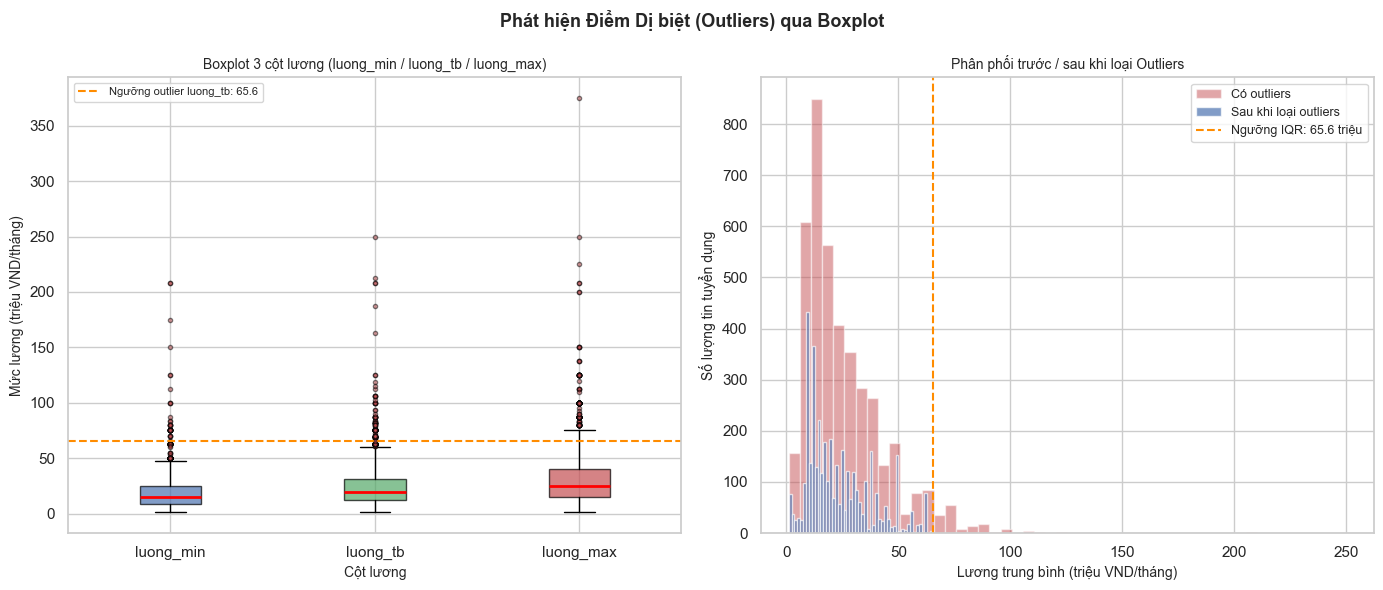

In [26]:
# Tính ngưỡng outlier bằng phương pháp IQR (tiêu chuẩn phổ biến)
Q1  = df_salary['luong_tb'].quantile(0.25)
Q3  = df_salary['luong_tb'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers    = df_salary[df_salary['luong_tb'] > upper_bound]
df_no_outliers = df_salary[df_salary['luong_tb'] <= upper_bound]

print("=== Phát hiện Outliers – phương pháp IQR ===")
print(f"  Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
print(f"  Ngưỡng dưới : {lower_bound:.2f} triệu  (thực tế min = {df_salary['luong_tb'].min():.2f})")
print(f"  Ngưỡng trên : {upper_bound:.2f} triệu")
print(f"  Số outliers  : {len(df_outliers):,} dòng ({len(df_outliers)/len(df_salary)*100:.1f}% tập lương số)")

if len(df_outliers) > 0:
    print(f"\n  Top 5 mức lương cao bất thường:")
    top5 = df_outliers.nlargest(5, 'luong_tb')[['ten_cong_viec', 'nhom_vi_tri', 'luong_tb']]
    for _, r in top5.iterrows():
        print(f"    {r['luong_tb']:>7.1f} triệu | {r['nhom_vi_tri']:<30} | {r['ten_cong_viec'][:40]}")

# ── Biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Phát hiện Điểm Dị biệt (Outliers) qua Boxplot",
    fontsize=13, fontweight='bold'
)

# --- Boxplot 3 cột lương cạnh nhau ---
ax1 = axes[0]
salary_cols = df[['luong_min', 'luong_tb', 'luong_max']].dropna()
bp = ax1.boxplot(
    [salary_cols['luong_min'], salary_cols['luong_tb'], salary_cols['luong_max']],
    tick_labels=['luong_min', 'luong_tb', 'luong_max'],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#C44E52', markersize=3, alpha=0.5),
)
colors = ['#4C72B0', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xlabel("Cột lương", fontsize=10)
ax1.set_ylabel("Mức lương (triệu VND/tháng)", fontsize=10)
ax1.set_title("Boxplot 3 cột lương (luong_min / luong_tb / luong_max)", fontsize=10)
ax1.axhline(upper_bound, color='darkorange', linestyle='--', linewidth=1.5,
             label=f'Ngưỡng outlier luong_tb: {upper_bound:.1f}')
ax1.legend(fontsize=8)

# --- So sánh phân phối: có và không có outliers ---
ax2 = axes[1]
ax2.hist(df_salary['luong_tb'], bins=50, alpha=0.5, color='#C44E52', label='Có outliers', edgecolor='white')
ax2.hist(df_no_outliers['luong_tb'], bins=50, alpha=0.7, color='#4C72B0', label='Sau khi loại outliers', edgecolor='white')
ax2.axvline(upper_bound, color='darkorange', linestyle='--', linewidth=1.5,
             label=f'Ngưỡng IQR: {upper_bound:.1f} triệu')
ax2.set_xlabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax2.set_ylabel("Số lượng tin tuyển dụng", fontsize=10)
ax2.set_title("Phân phối trước / sau khi loại Outliers", fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

##### Nhận xét:

- Theo phương pháp **IQR**: Q1 = 12.5 triệu, Q3 = 33.75 triệu, IQR = 21.25 triệu → ngưỡng outlier trên = **65.6 triệu/tháng**.
- Có **159 dòng (~3.8%)** vượt ngưỡng này, tập trung chủ yếu ở nhóm **Management / Architecture** và **Cloud / DevOps**.
- Boxplot cho thấy `luong_max` có **đuôi trên dài hơn** đáng kể so với `luong_min` và `luong_tb` – mức trần lương biến động mạnh hơn.
- Mức lương cao nhất trong dataset lên đến **250 triệu/tháng** – thường là CTO, Principal Engineer tại công ty công nghệ lớn hoặc FDI.
- Các outliers không phải sai số mà phản ánh thực tế phân khúc lương cao → không nên loại bỏ, chỉ cần ghi chú khi phân tích trung bình.

→ Nên ưu tiên dùng trung vị thay vì trung bình khi so sánh lương giữa các nhóm, vì trung bình bị kéo bởi ~3.8% outliers lương rất cao.

## **5. Phân tích tương quan đa biến sơ bộ (Bivariate Analysis) (Kim Yến)**

### **5.1. Mức lương trung bình theo Cấp độ kinh nghiệm**
Khảo sát mối tương quan sơ bộ giữa cột định tính `cap_do_kinh_nghiem` và cột định lượng `luong_tb` (sử dụng Boxplot/Barplot).

Thống kê lương theo Cấp độ kinh nghiệm (triệu VND/tháng):
                    so_luong  trung_binh  trung_vi   min     max
cap_do_kinh_nghiem                                              
Intern                   131        5.85      4.50  1.00   19.00
Fresher                  205       17.18     12.50  2.50   81.25
Junior                   354       19.43     16.25  1.25  102.50
Middle                   521       25.86     24.00  1.00   80.00
Senior                   528       45.83     40.48  1.00  250.00


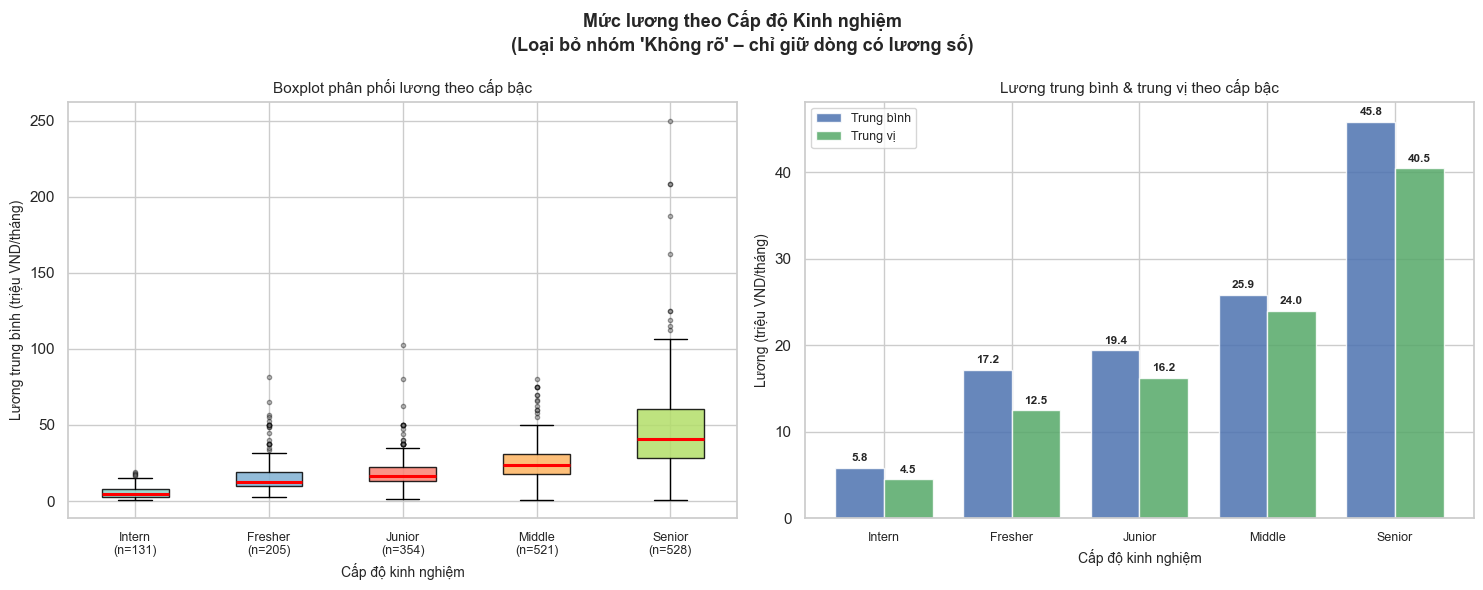

In [27]:
# Loại nhóm 'Không rõ' vì không cung cấp thông tin phân tích có nghĩa
df_exp = df_salary[df_salary['cap_do_kinh_nghiem'] != 'Không rõ'].copy()

# Xác định thứ tự seniority để biểu đồ hiển thị đúng chiều tăng dần
exp_order = ['Intern', 'Fresher', 'Junior', 'Middle', 'Senior']

# Thống kê lương theo cấp bậc
salary_exp = (
    df_exp.groupby('cap_do_kinh_nghiem')['luong_tb']
    .agg(so_luong='count', trung_binh='mean', trung_vi='median',
         min='min', max='max')
    .reindex(exp_order)
    .round(2)
)
print("Thống kê lương theo Cấp độ kinh nghiệm (triệu VND/tháng):")
print(salary_exp.to_string())

# ── Biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Mức lương theo Cấp độ Kinh nghiệm\n"
    "(Loại bỏ nhóm 'Không rõ' – chỉ giữ dòng có lương số)",
    fontsize=13, fontweight='bold'
)

palette_exp = ['#8dd3c7', '#80b1d3', '#fb8072', '#fdb462', '#b3de69']

# --- Boxplot: phân phối đầy đủ ---
ax1 = axes[0]
data_by_exp = [df_exp[df_exp['cap_do_kinh_nghiem'] == lvl]['luong_tb'].dropna() for lvl in exp_order]
labels_exp  = [f"{lvl}\n(n={len(d):,})" for lvl, d in zip(exp_order, data_by_exp)]

bp = ax1.boxplot(
    data_by_exp, tick_labels=labels_exp, patch_artist=True,
    medianprops=dict(color='red', linewidth=2.2),
    flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.4),
)
for patch, color in zip(bp['boxes'], palette_exp):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax1.set_xlabel("Cấp độ kinh nghiệm", fontsize=10)
ax1.set_ylabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax1.set_title("Boxplot phân phối lương theo cấp bậc", fontsize=11)
ax1.tick_params(axis='x', labelsize=9)

# --- Bar chart: trung bình & trung vị ---
ax2 = axes[1]
x  = range(len(exp_order))
w  = 0.38
tb_vals = salary_exp['trung_binh'].values
tv_vals = salary_exp['trung_vi'].values

bars1 = ax2.bar([i - w/2 for i in x], tb_vals, width=w, label='Trung bình', color='#4C72B0', alpha=0.85)
bars2 = ax2.bar([i + w/2 for i in x], tv_vals, width=w, label='Trung vị',   color='#55A868', alpha=0.85)

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_xticks(list(x))
ax2.set_xticklabels(exp_order, fontsize=9)
ax2.set_xlabel("Cấp độ kinh nghiệm", fontsize=10)
ax2.set_ylabel("Lương (triệu VND/tháng)", fontsize=10)
ax2.set_title("Lương trung bình & trung vị theo cấp bậc", fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

##### Nhận xét:

- Có **tương quan thuận chiều rõ ràng** giữa cấp độ kinh nghiệm và mức lương – biểu đồ bar chart tăng đều từ trái qua phải.
- **Intern**: TB ~5.9 triệu | **Fresher**: ~17.2 triệu | **Junior**: ~19.4 triệu | **Middle**: ~25.9 triệu | **Senior**: ~45.8 triệu.
- Bước nhảy lớn nhất là Middle → Senior (~+19.9 triệu/tháng) – cho thấy Senior được định giá vượt trội so với Middle trên thị trường IT Việt Nam.
- Mức chênh lệch Fresher → Junior khá nhỏ (~2.2 triệu) – hai cấp này có thể được doanh nghiệp đánh đồng trong nhiều trường hợp.
- Boxplot Senior có IQR rộng nhất (khoảng tứ phân vị lớn hơn các cấp khác) → lương Senior phân tán mạnh, phụ thuộc nhiều vào lĩnh vực và công ty.
- Senior được trả gấp ~7.8× so với Intern và ~2.7× so với Junior.

→ Đầu tư phát triển kỹ năng để đạt cấp Senior mang lại lợi ích lương cao hơn hẳn – đây là ngưỡng phân hóa thu nhập rõ nét nhất trong ngành IT.

### **5.2. Mức lương trung bình theo các Nhóm vị trí công việc**
So sánh mức lương trung bình chi trả giữa các nhóm công việc IT khác nhau.

Lương trung bình theo Nhóm vị trí (triệu VND/tháng) – sắp xếp giảm dần:
                             so_luong  trung_binh  trung_vi
nhom_vi_tri                                                
Management / Architecture         205       41.24     35.00
Cloud / DevOps / SRE              158       39.94     35.00
Data Engineering / Database       119       34.71     31.25
Mobile / Game / Embedded          338       30.27     25.00
AI / ML / Data Science            420       28.73     22.50
Software Development             1220       27.99     25.00
Product / Business / UX           188       27.57     25.00
QA / Testing                      218       27.12     25.00
Cybersecurity                     117       24.33     20.00
IT Support / ERP                  530       15.02     12.50
Other                             644       14.37     12.50


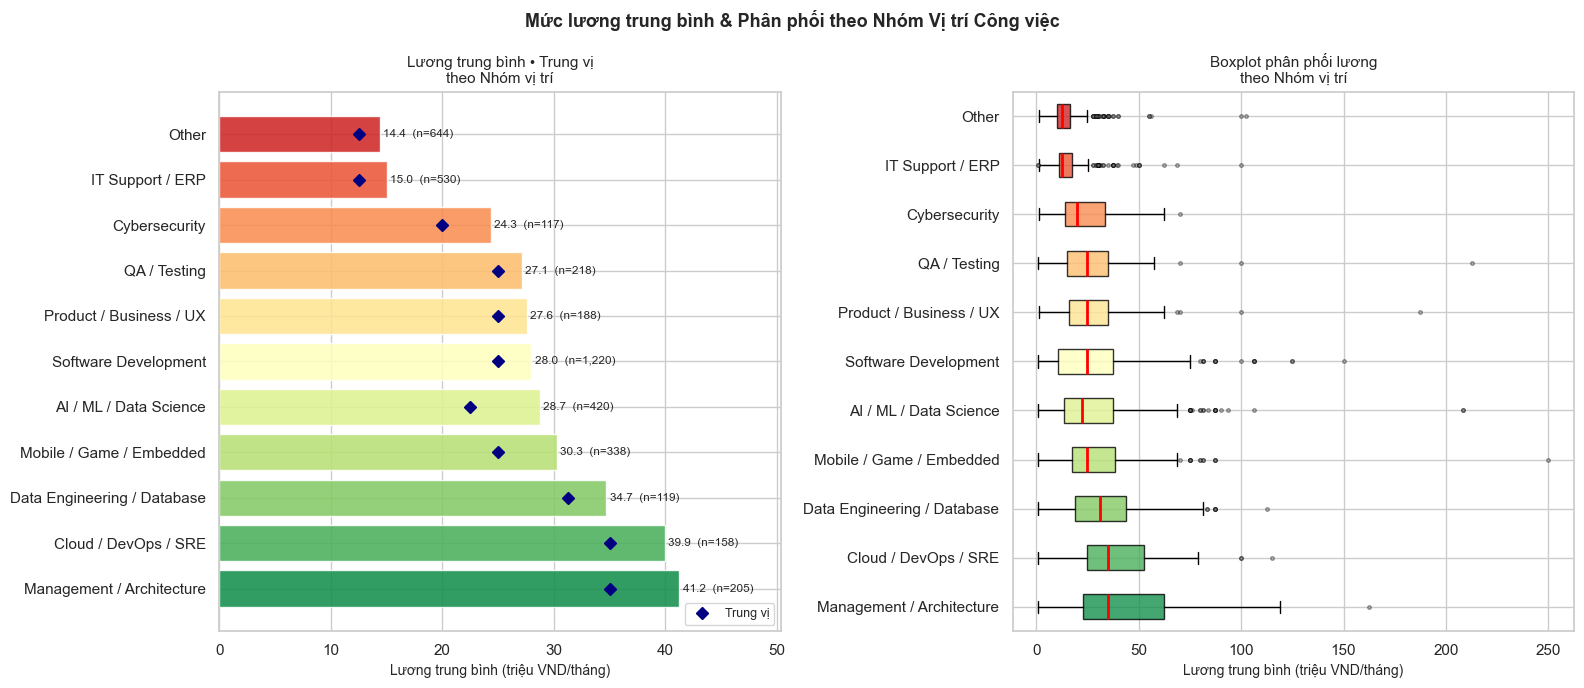

In [28]:
# Tính lương trung bình và trung vị theo từng nhóm vị trí
salary_role = (
    df_salary.groupby('nhom_vi_tri')['luong_tb']
    .agg(so_luong='count', trung_binh='mean', trung_vi='median')
    .sort_values('trung_binh', ascending=False)
    .round(2)
)
print("Lương trung bình theo Nhóm vị trí (triệu VND/tháng) – sắp xếp giảm dần:")
print(salary_role.to_string())

# ── Biểu đồ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Mức lương trung bình & Phân phối theo Nhóm Vị trí Công việc",
    fontsize=13, fontweight='bold'
)

role_order = salary_role.index.tolist()   # thứ tự từ cao → thấp
colors_bar  = sns.color_palette('RdYlGn', len(role_order))[::-1]

# --- Bar chart lương trung bình ---
ax1 = axes[0]
bars = ax1.barh(
    role_order,
    salary_role['trung_binh'],
    color=colors_bar, alpha=0.88, edgecolor='white'
)
# Vẽ đường trung vị
for i, (role, row) in enumerate(salary_role.iterrows()):
    ax1.plot(row['trung_vi'], i, marker='D', color='navy', markersize=6, zorder=5)

ax1.plot([], [], marker='D', color='navy', linestyle='None',
          markersize=6, label='Trung vị')

# Label số lên từng bar
for bar, (_, row) in zip(bars, salary_role.iterrows()):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['trung_binh']:.1f}  (n={int(row['so_luong']):,})",
             va='center', fontsize=8.5)

ax1.set_xlabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax1.set_title("Lương trung bình • Trung vị\ntheo Nhóm vị trí", fontsize=11)
ax1.legend(fontsize=9, loc='lower right')
ax1.set_xlim(0, salary_role['trung_binh'].max() * 1.22)

# --- Boxplot phân phối ---
ax2 = axes[1]
data_by_role = [df_salary[df_salary['nhom_vi_tri'] == r]['luong_tb'].dropna() for r in role_order]

bp2 = ax2.boxplot(
    data_by_role,
    vert=False,
    tick_labels=role_order,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='grey', markersize=2.5, alpha=0.4),
)
for patch, color in zip(bp2['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_xlabel("Lương trung bình (triệu VND/tháng)", fontsize=10)
ax2.set_title("Boxplot phân phối lương\ntheo Nhóm vị trí", fontsize=11)

plt.tight_layout()
plt.show()

##### Nhận xét:

- **Management / Architecture** dẫn đầu (~41.2 triệu TB) – phản ánh vai trò quyết định và trách nhiệm cao của nhóm này.
- **Cloud / DevOps / SRE** đứng thứ 2 (~39.9 triệu) – nhu cầu cao, nguồn cung hạn chế đẩy mức lương lên cao.
- **Data Engineering / Database** (~34.7 triệu) và **Mobile / Game / Embedded** (~30.3 triệu) ở nhóm trung-cao.
- **IT Support / ERP** (~15.0 triệu) và **Other** (~14.4 triệu) thấp nhất – tương ứng với tính chất công việc vận hành, ít đòi hỏi kỹ năng chuyên sâu hơn.
- Khoảng cách lương giữa nhóm cao nhất và thấp nhất: **~26.8 triệu/tháng** – chênh lệch rất đáng kể.
- Boxplot cho thấy **Management** và **Cloud/DevOps** có IQR rộng nhất → phân tán lương cao, cùng nhóm nhưng lương có thể rất khác nhau.
- **AI / ML / Data Science** (~28.7 triệu) có mức lương ổn định, đang tiệm cận nhóm Cloud/DevOps.

→ Chọn đúng lĩnh vực kỹ thuật (Cloud, DevOps, Data Engineering) ảnh hưởng rất lớn đến thu nhập, đôi khi còn quan trọng hơn cả cấp bậc kinh nghiệm.

### **5.3. Phân bố các Cấp độ kinh nghiệm theo từng Nhóm vị trí công việc**
Sử dụng biểu đồ cột chồng (Stacked Bar Chart) hoặc đếm tần suất chéo (crosstab) để xem cơ cấu kinh nghiệm yêu cầu ở mỗi mảng công việc IT.

Số lượng tin tuyển dụng theo Nhóm vị trí × Cấp độ kinh nghiệm:
cap_do_kinh_nghiem           Intern  Fresher  Junior  Middle  Senior
nhom_vi_tri                                                         
IT Support / ERP                 22       28      43      48      16
Other                            50      101     100     111      44
Mobile / Game / Embedded         23       40      80     120     120
Software Development             39       90     208     336     335
QA / Testing                      9       20      44      67     105
AI / ML / Data Science           36       37      56     106     178
Data Engineering / Database       1       12      13      46      65
Product / Business / UX           2       14      15      44      72
Cybersecurity                     5       12      10      37      72
Cloud / DevOps / SRE              3        8      20      73     128
Management / Architecture         3        8       7      34     309

Tỷ lệ % (theo hàng):
cap_do_kinh_nghiem

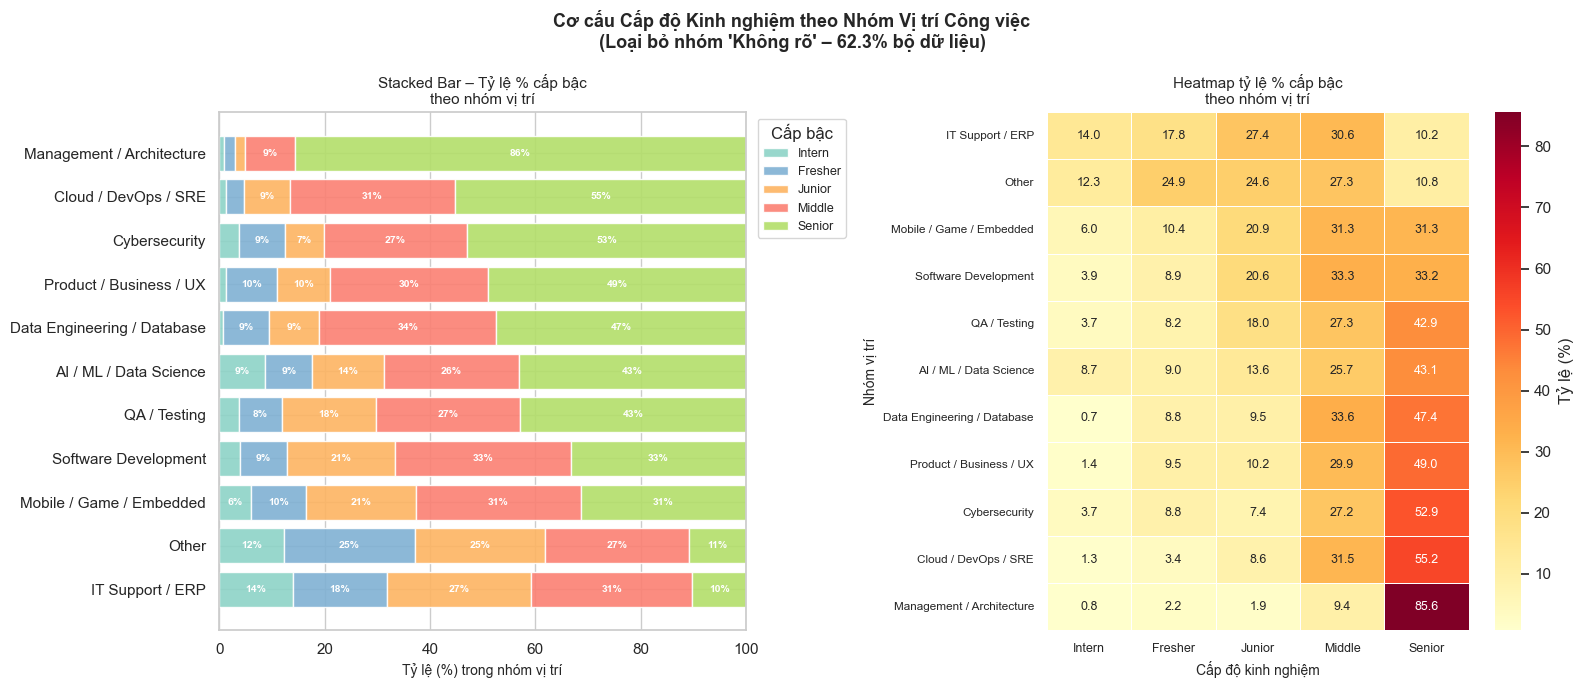

In [29]:
# Loại nhóm 'Không rõ' để biểu đồ có ý nghĩa thống kê
df_cross = df[df['cap_do_kinh_nghiem'] != 'Không rõ'].copy()

exp_order = ['Intern', 'Fresher', 'Junior', 'Middle', 'Senior']

# Crosstab: đếm số lượng theo nhóm vị trí × cấp bậc
ct_count = pd.crosstab(
    df_cross['nhom_vi_tri'],
    df_cross['cap_do_kinh_nghiem']
)[exp_order]   # đảm bảo thứ tự cột đúng

# Chuyển sang tỷ lệ % để so sánh công bằng giữa nhóm lớn/nhỏ
ct_pct = ct_count.div(ct_count.sum(axis=1), axis=0) * 100

# Sắp xếp nhóm vị trí theo tỷ lệ Senior giảm dần
ct_pct_sorted = ct_pct.sort_values('Senior', ascending=True)
ct_count_sorted = ct_count.loc[ct_pct_sorted.index]

print("Số lượng tin tuyển dụng theo Nhóm vị trí × Cấp độ kinh nghiệm:")
print(ct_count_sorted.to_string())
print()
print("Tỷ lệ % (theo hàng):")
print(ct_pct_sorted.round(1).to_string())

# ── Biểu đồ ──────────────────────────────────────────────────────────────
palette_stacked = {
    'Intern' : '#8dd3c7',
    'Fresher': '#80b1d3',
    'Junior' : '#fdb462',
    'Middle' : '#fb8072',
    'Senior' : '#b3de69',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Cơ cấu Cấp độ Kinh nghiệm theo Nhóm Vị trí Công việc\n"
    "(Loại bỏ nhóm 'Không rõ' – 62.3% bộ dữ liệu)",
    fontsize=13, fontweight='bold'
)

# --- Stacked bar chart tỷ lệ % ---
ax1 = axes[0]
bottom = np.zeros(len(ct_pct_sorted))
for level in exp_order:
    values = ct_pct_sorted[level].values
    bars = ax1.barh(
        ct_pct_sorted.index, values, left=bottom,
        label=level, color=palette_stacked[level], alpha=0.9
    )
    # Ghi % lên thanh nếu đủ rộng (> 5%)
    for bar, val, bot in zip(bars, values, bottom):
        if val > 5:
            ax1.text(
                bot + val/2, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}%", ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white'
            )
    bottom += values

ax1.set_xlim(0, 100)
ax1.set_xlabel("Tỷ lệ (%) trong nhóm vị trí", fontsize=10)
ax1.set_title("Stacked Bar – Tỷ lệ % cấp bậc\ntheo nhóm vị trí", fontsize=11)
ax1.legend(title='Cấp bậc', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# --- Heatmap tỷ lệ % ---
ax2 = axes[1]
sns.heatmap(
    ct_pct_sorted.round(1),
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax2, cbar_kws={'label': 'Tỷ lệ (%)'},
    annot_kws={'size': 9}
)
ax2.set_xlabel("Cấp độ kinh nghiệm", fontsize=10)
ax2.set_ylabel("Nhóm vị trí", fontsize=10)
ax2.set_title("Heatmap tỷ lệ % cấp bậc\ntheo nhóm vị trí", fontsize=11)
ax2.tick_params(axis='x', labelsize=9)
ax2.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()

##### Nhận xét:

- **Cloud / DevOps / SRE** và **Cybersecurity** có tỷ lệ Senior cao nhất – hai lĩnh vực này đòi hỏi kinh nghiệm thực chiến cao, rất ít cơ hội cho người mới.
- **Management / Architecture** gần như toàn Senior/Middle – hợp lý vì đây là vai trò lãnh đạo kỹ thuật.
- **IT Support / ERP** và **QA / Testing** có tỷ lệ Fresher/Junior cao hơn so với các nhóm chuyên sâu – cửa ngõ phù hợp cho sinh viên mới ra trường.
- **AI / ML / Data Science** có sự phân bố **đa dạng nhất** từ Fresher đến Senior – cho thấy thị trường AI đang tuyển ở nhiều cấp độ, không chỉ chuyên gia.
- Heatmap xác nhận: **không có nhóm nào tuyển Intern số lượng lớn** – Intern chiếm tỷ lệ nhỏ ở mọi nhóm, nhiều nhất là IT Support và AI/ML.
- Stacked bar giúp so sánh trực quan hơn: nhóm nào nghiêng về màu xanh đậm (Senior) thì ngưỡng vào nghề cao hơn.

→ Sinh viên/người mới nên nhắm vào **IT Support, QA/Testing, AI/ML** để có cơ hội tham gia thị trường dễ hơn; Cloud/DevOps và Cybersecurity phù hợp hơn cho người đã có kinh nghiệm.